# Capstone Function 1
Detect likely contamination source in a two-dimensional area, such as a radiation field, where only proximity yeilds a non-zero reading.  The system uses Bayesian Optimization to tune detection parameters and reliably identify both strong and weak sources
| Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

## Notes
- Inputs are in range 0 to 1
- outputs very small - 0 if not close the source
-

## Initial Submission

This section contains the initial Bayesian Optimization implementation using BoTorch with Gaussian Process surrogate model and Expected Improvement acquisition function.

### Step 1: Import Required Libraries

Import necessary libraries for Bayesian Optimization, data handling, and visualization.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
PyTorch version: 2.10.0


### Step 2: Load and Display Initial Data

Load the initial input and output data for the radiation source detection problem.

In [2]:
# Load initial data
X_init = np.load('../../data/f1/initial_inputs.npy')
y_init = np.load('../../data/f1/initial_outputs.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape}")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

Initial Data Summary:
Input shape: (10, 2)
Output shape: (10,)

Input range: [0.0787, 0.8839]
Output range: [-0.003606, 0.000000]
Output mean: -0.000361
Output std: 0.001082

Best observed value: 0.000000
Best input location: [0.73102363 0.73299988]

First 5 samples:
  X[0] = [0.31940389 0.76295937], y[0] = 0.000000
  X[1] = [0.57432921 0.8798981 ], y[1] = 0.000000
  X[2] = [0.73102363 0.73299988], y[2] = 0.000000
  X[3] = [0.84035342 0.26473161], y[3] = 0.000000
  X[4] = [0.65011406 0.68152635], y[4] = -0.003606


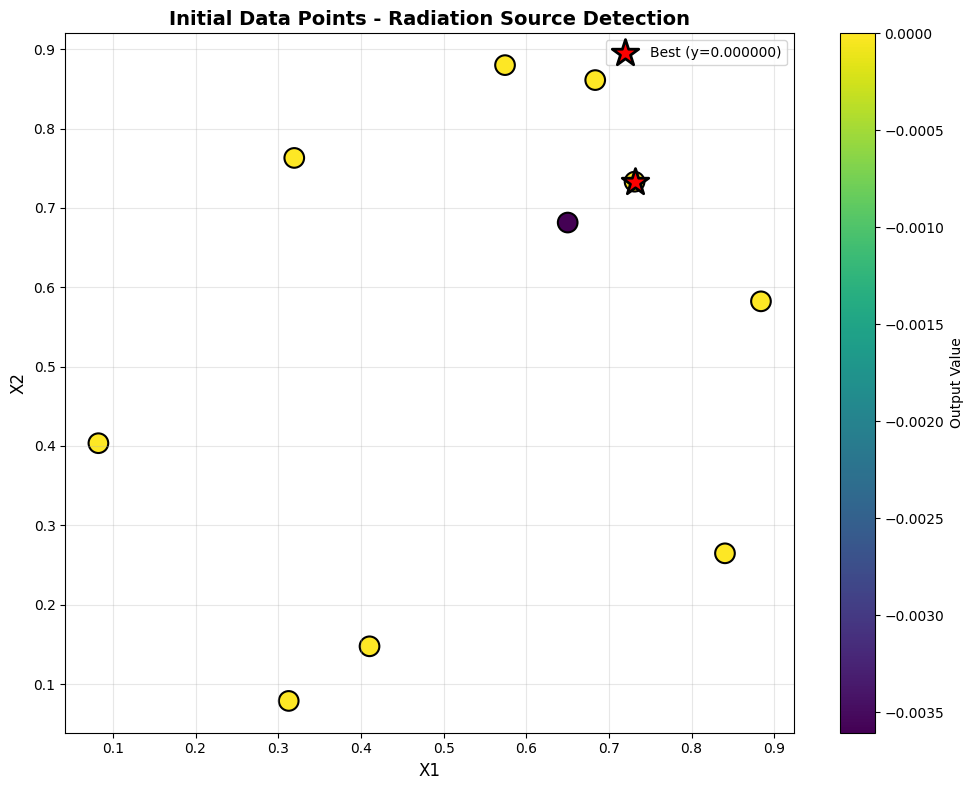

In [3]:
# Visualize initial data points in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=200, cmap='viridis', edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Output Value')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Initial Data Points - Radiation Source Detection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the best point
best_idx = y_init.argmax()
plt.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label=f'Best (y={y_init[best_idx]:.6f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Gaussian Process Kernel**: Matern 5/2 (BoTorch default)
   - **Why**: Provides a good balance between smoothness and flexibility for unknown functions
   - Suitable for radiation fields which may have smooth gradients near sources

2. **Acquisition Function**: Expected Improvement (EI)
   - **Why**: Simple, well-tested, and effective for maximization
   - Balances exploration (searching new areas) and exploitation (refining known good areas)
   - Works well with small sample sizes (10 initial points)

3. **Number of Restarts for Acquisition Optimization**: 10
   - **Why**: Ensures we find good candidates by starting from multiple random points
   - Important for avoiding local optima in acquisition function

4. **Number of Raw Samples**: 512
   - **Why**: Initial random sampling to find good starting points for optimization
   - Higher number increases chances of finding global optimum of acquisition function

5. **Input Bounds**: [0, 0.999999] for all dimensions
   - **Why**: Required by submission format - all inputs must be in range [0, 0.999999]

6. **Standardize Outputs**: Yes
   - **Why**: Outputs are very small (close to 0 when far from source)
   - Standardization helps GP model training and numerical stability

In [ ]:
# Define hyperparameters
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]  # Number of dimensions
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)
NUM_RESTARTS = 10  # Number of restarts for acquisition function optimization
RAW_SAMPLES = 512  # Number of initial random samples for acquisition optimization

print("Hyperparameters:")
print(f"  Input bounds: [0, 0.999999] for all {N_DIM} dimensions")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2 (default)")
print(f"  Number of restarts: {NUM_RESTARTS}")

print(f"  Raw samples: {RAW_SAMPLES}")
print(f"  Output standardization: Yes (SingleTaskGP handles this)")

Hyperparameters:
  Input bounds: [[0. 0.]
 [1. 1.]]
  Acquisition function: Expected Improvement (EI)
  GP Kernel: Matern 5/2 (default)
  Number of restarts: 10
  Raw samples: 512
  Output standardization: Yes (SingleTaskGP handles this)


### Step 4: Build Gaussian Process Surrogate Model

Create and train a Gaussian Process model on the initial data. The GP learns the relationship between inputs and outputs.

In [6]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)  # Add dimension for single output

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create Gaussian Process model
# SingleTaskGP automatically standardizes outputs for better numerical stability
gp_model = SingleTaskGP(X_train, y_train)

# Define the marginal log likelihood
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

# Fit the GP model to the data
print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")

Training data shape: X=torch.Size([10, 2]), y=torch.Size([10, 1])

Training Gaussian Process model...
✓ Model training complete!

Learned GP Hyperparameters:
  Noise variance: 0.006733
  Length scales: [[0.04062811 0.08667175]]


### Step 5: Optimize Acquisition Function to Propose Next Sample

Use Expected Improvement to find the next most promising point to evaluate.

In [7]:
# Create Expected Improvement acquisition function
# best_f is the best observed value so far
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize the acquisition function to find the next candidate point
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,  # Number of candidates to generate
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Extract the proposed next point
next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement value: {acq_value.item():.6f}")

Best observed value: 0.000000

Optimizing acquisition function...
✓ Optimization complete!

Proposed next sample point:
  X_next = [0.74055568 0.83834038]
  Expected Improvement value: 0.000426


### Step 6: Visualize Surrogate Function

Visualize the GP mean prediction and uncertainty across the 2D search space.

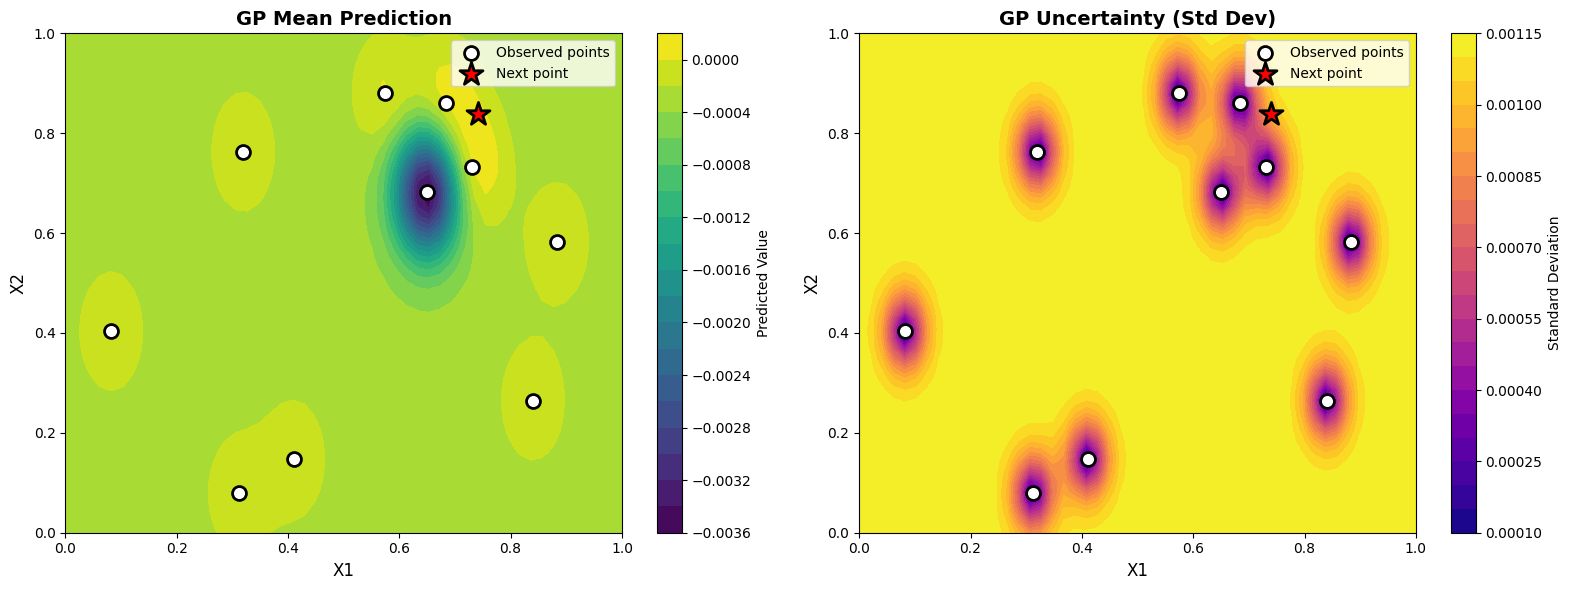

The GP predicts highest values near regions with observed high outputs.
Uncertainty is highest in unexplored regions.


In [8]:
# Create a grid for visualization
n_grid = 50
x1 = np.linspace(0, 1, n_grid)
x2 = np.linspace(0, 1, n_grid)
X1_grid, X2_grid = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_grid_torch = torch.tensor(X_grid, dtype=torch.float64)

# Get GP predictions
gp_model.eval()
with torch.no_grad():
    posterior = gp_model.posterior(X_grid_torch)
    mean = posterior.mean.numpy().reshape(n_grid, n_grid)
    std = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GP Mean Prediction
im1 = axes[0].contourf(X1_grid, X2_grid, mean, levels=20, cmap='viridis')
axes[0].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[0].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('GP Mean Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Predicted Value')

# Plot 2: GP Uncertainty (Standard Deviation)
im2 = axes[1].contourf(X1_grid, X2_grid, std, levels=20, cmap='plasma')
axes[1].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[1].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('GP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Standard Deviation')

plt.tight_layout()
plt.show()

print(f"The GP predicts highest values near regions with observed high outputs.")
print(f"Uncertainty is highest in unexplored regions.")

### Step 7: Visualize Acquisition Function

Show the Expected Improvement values across the search space, indicating where the algorithm wants to sample next.

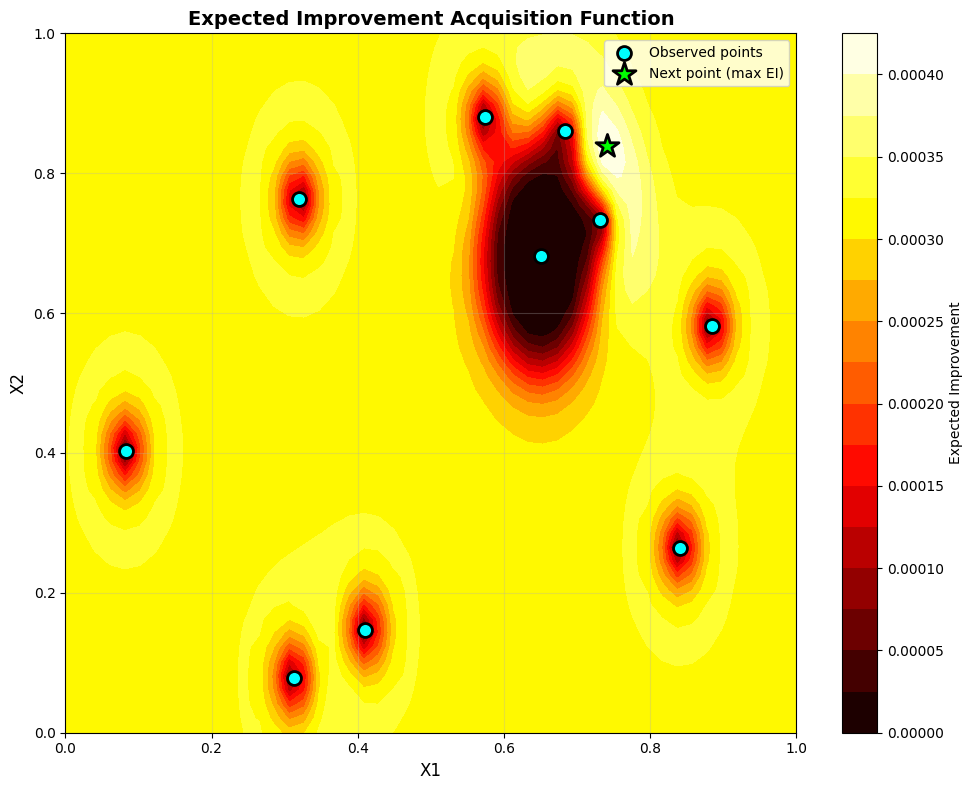

The next point is selected where Expected Improvement is maximized.
This balances exploring uncertain regions and exploiting promising areas.


In [9]:
# Compute Expected Improvement values across the grid
with torch.no_grad():
    ei_values = EI(X_grid_torch.unsqueeze(1)).numpy().reshape(n_grid, n_grid)

# Visualize Expected Improvement
plt.figure(figsize=(10, 8))
im = plt.contourf(X1_grid, X2_grid, ei_values, levels=20, cmap='hot')
plt.scatter(X_init[:, 0], X_init[:, 1], c='cyan', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
plt.scatter(next_point[0], next_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point (max EI)', zorder=6)
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Expected Improvement Acquisition Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The next point is selected where Expected Improvement is maximized.")
print(f"This balances exploring uncertain regions and exploiting promising areas.")

### Step 8: Track Optimization Progress

Monitor the best observed value over iterations to assess convergence.

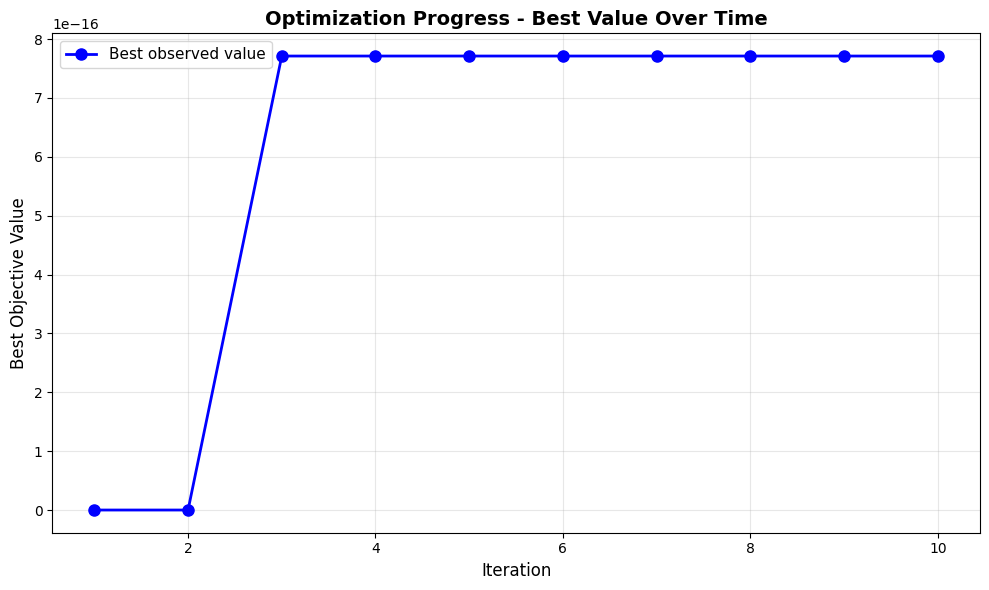

Starting best value: 0.000000
After 10 initial samples, awaiting next evaluation...

Next submission: [0.74055568 0.83834038]


In [10]:
# Track the best value found so far at each iteration
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Objective Value', fontsize=12)
plt.title('Optimization Progress - Best Value Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples, awaiting next evaluation...")
print(f"\nNext submission: {next_point}")

### Step 9: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [7]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

SUBMISSION QUERY FOR FUNCTION 1

0.740501-0.838613


Coordinates breakdown:
  x1 = 0.740501
  x2 = 0.838613

EI value: 0.000426
  -> Low EI: Approaching convergence
Current best observed: 0.000000


### Summary

**Initial Submission Complete**

- Loaded 10 initial data points for 2D radiation source detection
- Built Gaussian Process surrogate model with Matern 5/2 kernel
- Used Expected Improvement acquisition function
- Proposed next sample point for evaluation
- Visualized surrogate function, uncertainty, and acquisition landscape

**Next Steps:**
1. Submit the proposed point for evaluation
2. Receive the observation result
3. Add to dataset and retrain model
4. Propose next point (repeat process)

The optimization is designed to efficiently locate radiation sources by balancing exploration of the 2D space with exploitation of promising regions showing non-zero readings.